In [24]:
from utils import CliffWorld, plot_performance
import importlib
import agents
import gymnasium as gym
importlib.reload(agents)
from agents import QLearningAgent, SARSA, Agent

import numpy as np
import matplotlib.pyplot as plt


##  Grid Worlds

As pointed out, bandits only have a single state and immediate rewards for our actions. Many problems we are interested in have multiple states and delayed rewards, i.e. we won't know if the choices we made will pay off over time, or which actions we took contributed to the outcomes we observed.

In order to explore these ideas, we turn the a common problem setting: the grid world. Grid worlds are simple environments where each state corresponds to a tile on a 2D grid, and the only actions the agent can take are to move up, down, left, or right across the grid tiles. The agent's job is almost always to find a way to a goal tile in the most direct way possible while overcoming some maze or other obstacles, either static or dynamic.

For our discussion we will be looking at the classic Cliff World, or Cliff Walker, environment. This is a 4x10 grid with a starting position in the lower-left and the goal position in the lower-right. Every tile between these two is the "cliff", and should the agent enter the cliff, they will receive a -100 reward and be sent back to the starting position. Every tile other than the cliff produces a -1 reward when entered. The goal tile ends the episode after taking any action from it.

<img alt="CliffWorld" width="577" height="308" src="https://raw.githubusercontent.com/NeuromatchAcademy/course-content/master/tutorials/static/W3D4_Tutorial3_CliffWorld.png">

Given these conditions, the maximum achievable reward is -11 (1 up, 9 right, 1 down). Using negative rewards is a common technique to encourage the agent to move and seek out the goal state as fast as possible.

In [7]:
env = CliffWorld()
env.n_actions, env.n_states

(4, 40)

In [8]:
state = env.init_state  # initialize state
print(state)

0


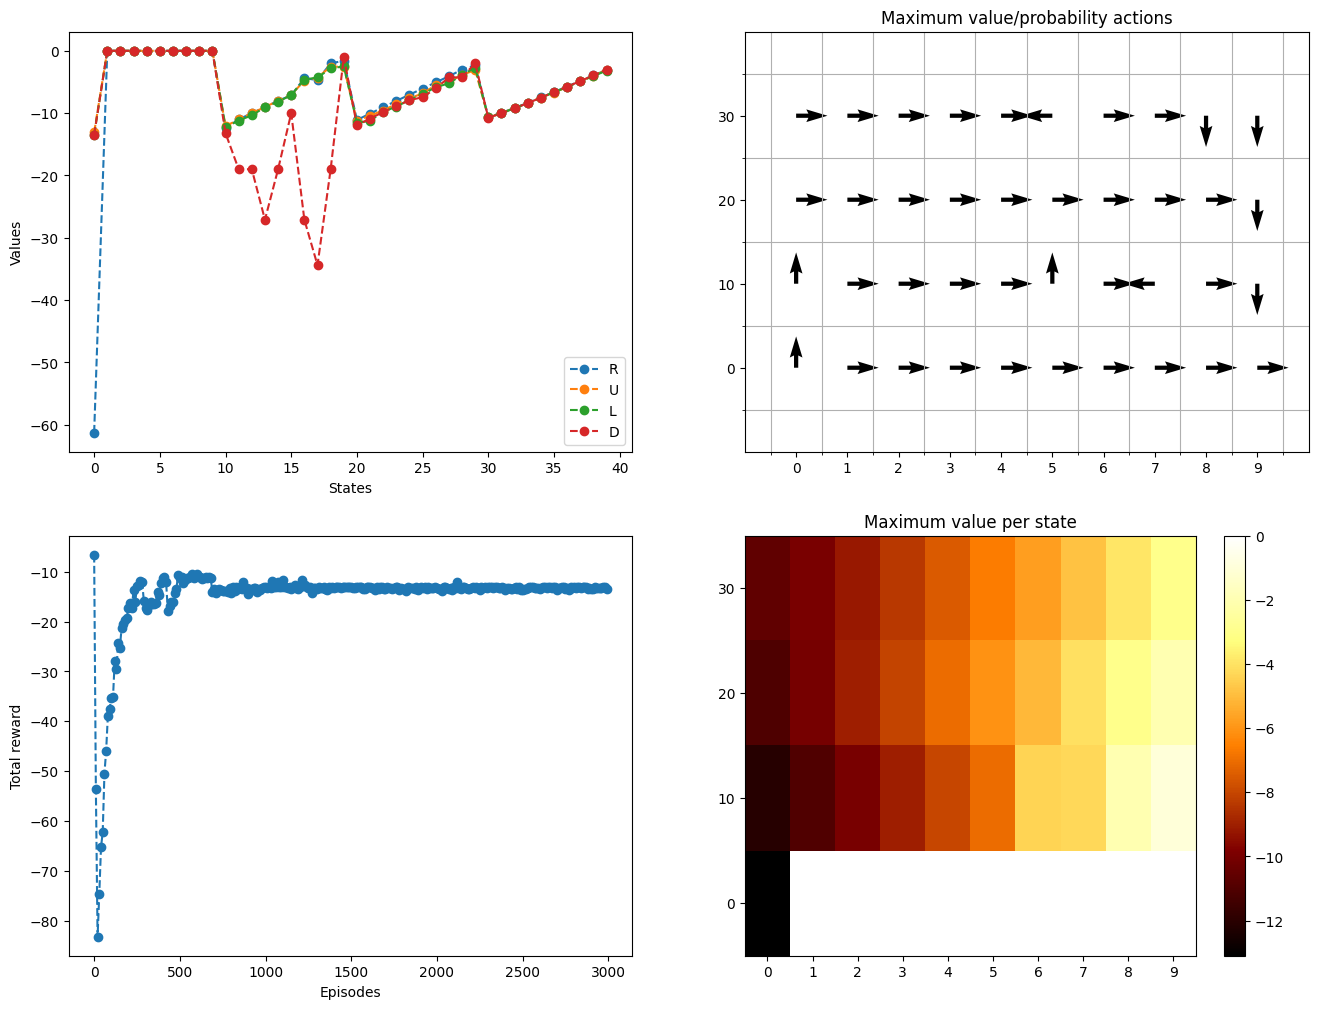

In [17]:
# set for reproducibility, comment out / change seed value for different results
np.random.seed(5)
# episodes/trials
n_episodes = 3000
max_steps = 100

# environment initialization
env = CliffWorld()
# solve Cliff World using Q-learning
# agent = QLearningAgent(env.n_states, env.n_actions)
agent = SARSA(env.n_states, env.n_actions)

reward_sums = np.zeros(n_episodes)

# Loop over episodes
for episode in range(n_episodes):
    state = env.init_state  # initialize state
    reward_sum = 0

    for t in range(max_steps):
      # choose next action
        action = agent.choose(state)

      # observe outcome of action on environment
        next_state, reward = env.get_outcome(state, action)

      # update value function
        agent.update(state, action, reward, next_state)

      # sum rewards obtained
        reward_sum += reward

        if next_state is None:
            break  # episode ends
        state = next_state
        reward_sums[episode] = reward_sum

reward_sums_qlearning = reward_sums
# Plot results
plot_performance(env, agent.q_values, reward_sums)


## GYM environment (OpenAI)
#### https://gymnasium.farama.org/

In [ ]:
env = gym.make('CliffWalking-v1')
env.action_space.n, env.observation_space.n


(np.int64(4), np.int64(48))

In [ ]:
import gymnasium as gym
import time

# Create the CartPole environment with human rendering
env = gym.make("CartPole-v1", render_mode="human")

num_episodes = 5  # number of episodes to run
max_steps = 500   # max steps per episode

for ep in range(num_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        env.render()  # show the environment
        action = env.action_space.sample()  # take a random action
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        time.sleep(0.01)  # slow down the simulation a bit for visualization

    print(f"Episode {ep+1}: Total Reward = {total_reward}")

env.close()


Episode 1: Total Reward = 17.0
Episode 2: Total Reward = 15.0
Episode 3: Total Reward = 16.0
Episode 4: Total Reward = 20.0
Episode 5: Total Reward = 21.0
